In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


In [2]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')


In [3]:
# self.path = path
raw_balance = nc.Dataset(os.path.join('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps', "balance.nc"))


In [4]:
print(raw_balance['gs'])

<class 'netCDF4.Variable'>
float64 gs(3, ny_plus2, nx_plus2)
unlimited dimensions: 
current shape = (3, 40, 188)
filling on, default _FillValue of 9.969209968386869e+36 used


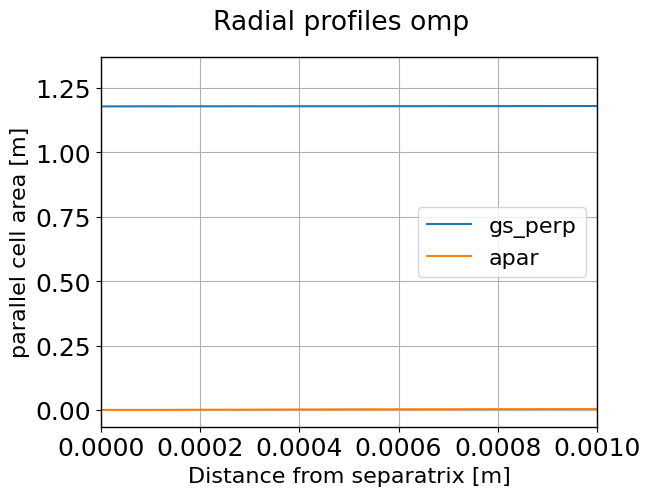

1.2047962549668805


In [5]:
fline = case.get_1d_radial_data(
    ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total', 'fhtx', 'gs_par', 'gs_perp'], 
    region='omp',
    keep_geometry=True
)
fig,ax = plt.subplots()
ax.plot(fline['dist'],fline['gs_perp'], label='gs_perp')
# ax.scatter(fline['dist'],fline['gs_par'], label='gs_par')
ax.plot(fline['dist'], fline['apar'], label='apar')
ax.set_xbound(0, 0.001)
# ax.set_ybound(0, 0.01)
ax.set_ylabel(r"parallel cell area [m]")
ax.set_xlabel(r"Distance from separatrix [m]")
ax.legend()
fig.suptitle('Radial profiles omp')
plt.show()

print(fline['gs_par'].values[0]/fline['gs_par'].values[2])

Text(0.5, 0.98, 'Poloidal profiles outer_lower')

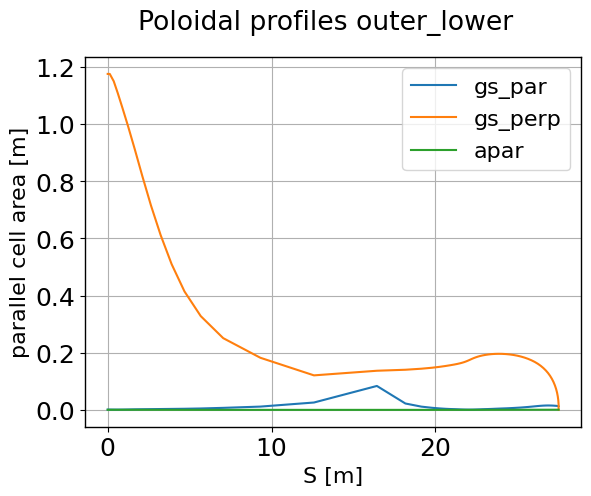

In [6]:
fline = case.get_1d_poloidal_data(
    params=["gs_par", "gs_perp", 'Bpol'],   
    region='outer_lower',
    sepadd=0,

)

fig,ax = plt.subplots()
ax.plot(fline['Spar'],fline['gs_par'], label='gs_par')
ax.plot(fline['Spar'],fline['gs_perp'], label='gs_perp')
ax.plot(fline['Spar'],fline['apar'], label='apar')
ax.legend()
ax.set_xlabel(r"S [m]")
ax.set_ylabel(r"parallel cell area [m]")
fig.suptitle('Poloidal profiles outer_lower')

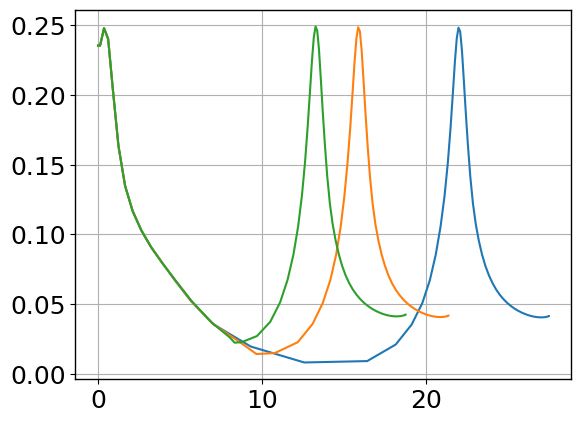

In [7]:
fig,ax = plt.subplots()
for i in range(3):
    fline = case.get_1d_poloidal_data(
        params=["gs_par", "gs_perp", 'Bpol'],   
        region='outer_lower',
        sepadd=i,

    )

    ax.plot(fline['Spar'],fline['Bpol'], label=f'sepadd={i}')



# Get $\lambda_q$ 

Exponential fit:
  λq: 2.27 mm
  Amplitude: 3.57e+06 W/m²


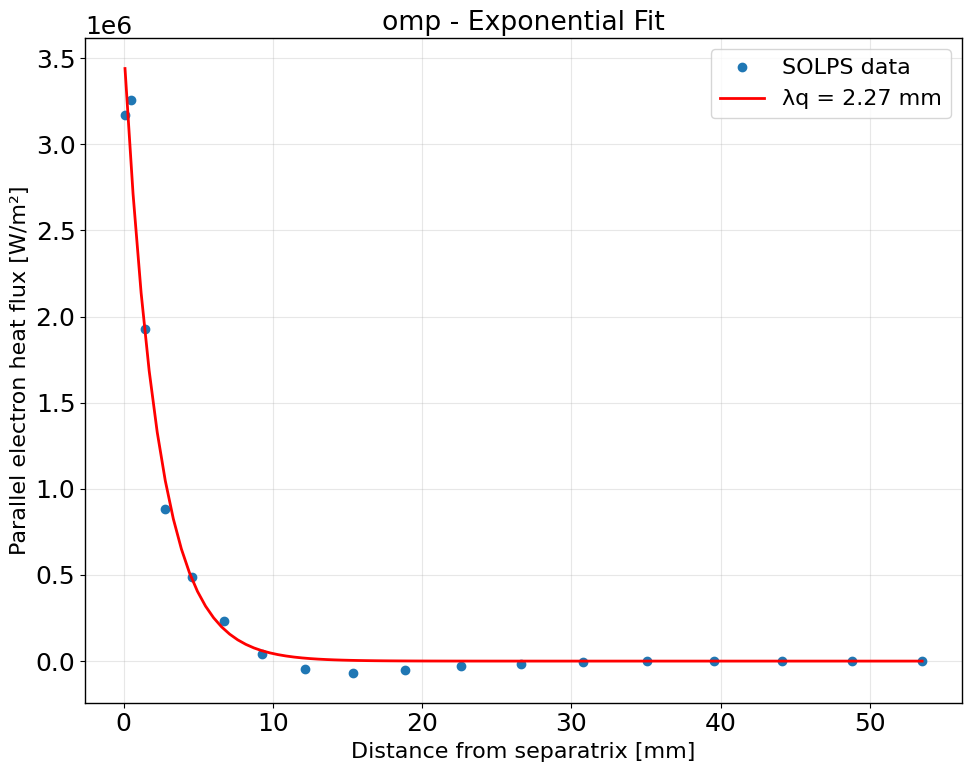

Initial guesses: q0=6.51e+06, λq=5.00mm, q_bg=0.00e+00

Eich fit parameters:
  q₀: 7.19e+06 ± 2.54e+05 W/m²
  λq: 3.36 ± 0.29 mm
  q_BG: 1.48e-21 ± 4.05e+04 W/m²


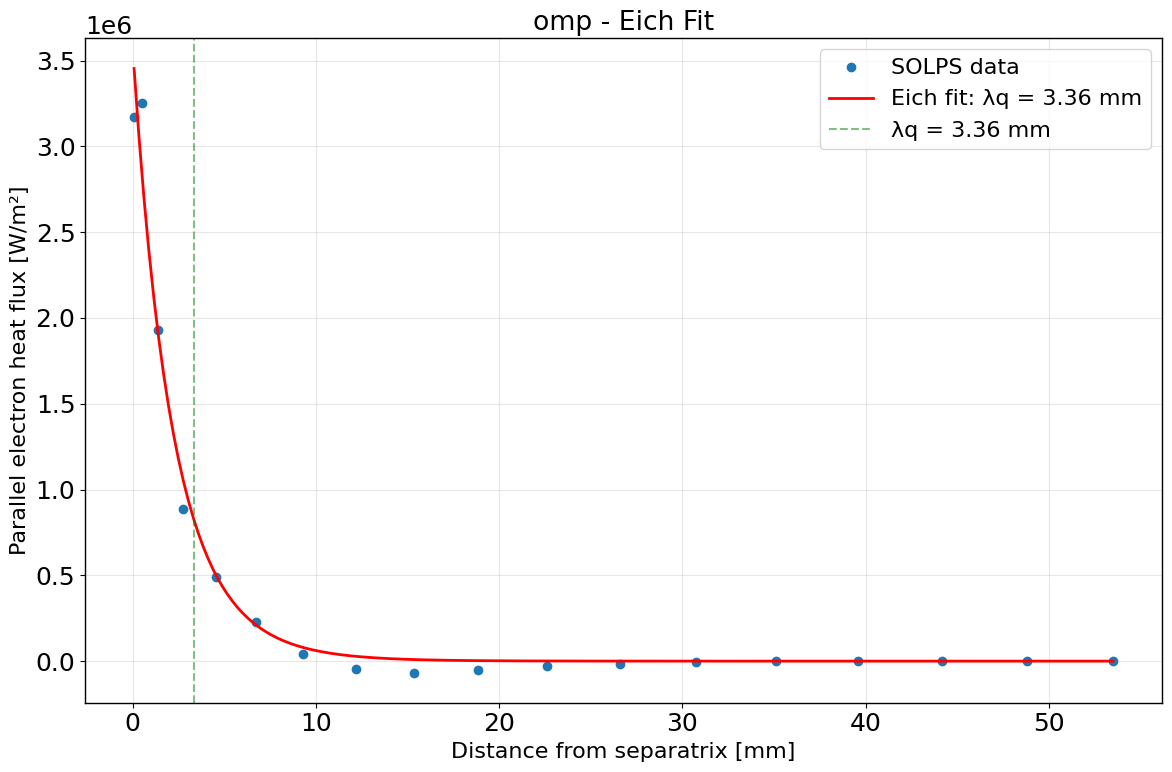

Gaussian fit parameters:
  Peak amplitude (a): 1.03e+07 W/m²
  Peak position (r0): -6.12 mm
  Sigma: 4.15 mm
  FWHM: 9.78 mm


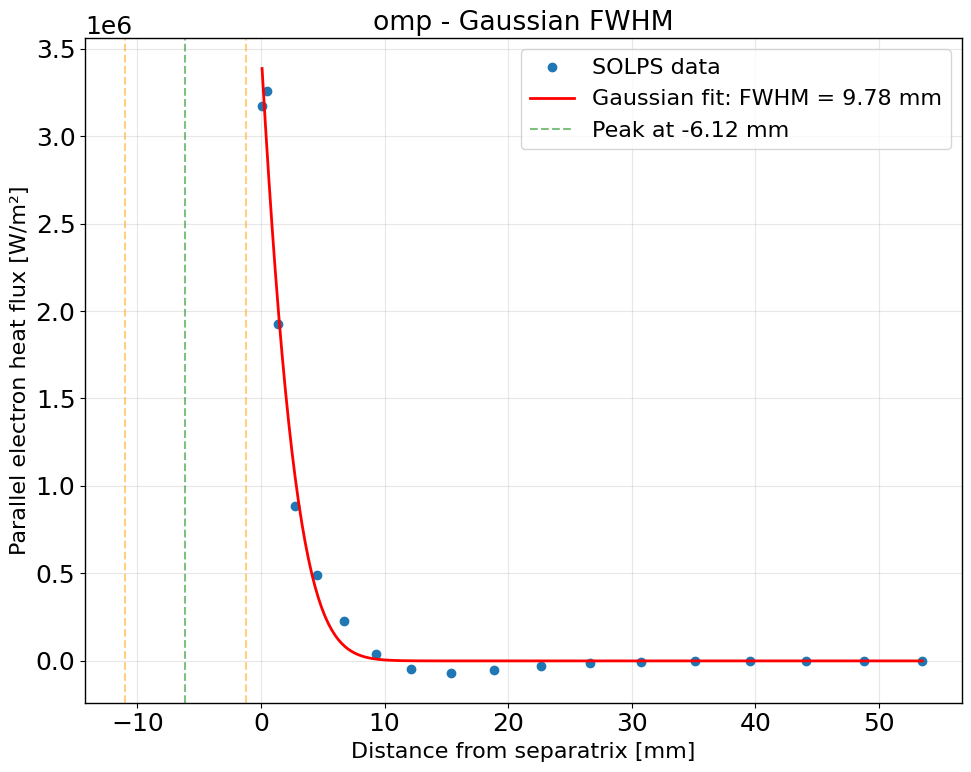

In [8]:
from scipy.optimize import curve_fit
from scipy.special import erfc
import numpy as np
import matplotlib.pyplot as plt


def get_lambda_q(case, region="omp", method="exponential", plot=True, 
                 range=(0.0, None), go_from_peak=False):
    """
    Fit parallel heat flux to extract characteristic width parameters.
    
    Parameters
    ----------
    case : SOLPSCase
        SOLPS case object
    region : str
        Region to analyze ('omp', 'outer_lower_xpoint', etc.)
    method : str
        Fitting method:
        - 'exponential': Simple exponential decay q = a * exp(-r/λq)
        - 'eich': Eich profile with erfc (Reference: Eich et al., Nuclear Fusion 53 (2013))
        - 'gaussian': Gaussian profile to calculate FWHM
    plot : bool
        Whether to plot the fit
    range : tuple
        (lower, upper) bounds for radial distance filtering
    go_from_peak : bool
        For exponential fit, start from peak q_parallel position
        
    Returns
    -------
    dict
        Dictionary containing fit results, keys depend on method:
        - exponential: {'lambda_q': float, 'amplitude': float}
        - eich: {'lambda_q': float, 'q0': float, 'q_bg': float, 'errors': dict}
        - gaussian: {'fwhm': float, 'sigma': float, 'peak': float, 'r0': float}
    """
    # Load data
    fline = case.get_1d_radial_data(
        ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total', 'fhtx', 'fhty'], 
        region=region,
        keep_geometry=True
    )
    
    ds = fline.copy()

    # Filter lower bound
    if range[0] is not None:
        sep_indx = np.searchsorted(ds['dist'].values, range[0], side='right')
        ds = ds.iloc[sep_indx:]

    # Filter upper bound
    if range[1] is not None:
        upper_indx = np.searchsorted(ds['dist'].values, range[1], side='right')
        ds = ds.iloc[:upper_indx]
    
    # Optionally clip data to start from peak (for exponential method)
    if go_from_peak and method == "exponential":
        q_parallel = ds['fhex_total']/ds['apar']
        peak_idx = q_parallel.idxmax()
        pos_from_peak = ds.index.get_loc(peak_idx)
        ds = ds.iloc[pos_from_peak:]
    
    # Select heat flux field based on method
    if method == "eich":
        q_parallel = ds['fhex_total'].values / ds['apar'].values  # Use fhtx for Eich
    else:
        q_parallel = ds['fhex_total'].values / ds['apar'].values
    
    s_bar = ds['dist'].values  # radial distance from separatrix
    
    # ========== Method-specific fitting ==========
    
    if method == "exponential":
        # Simple exponential decay fit
        def fit_func(r, a, lmq):
            return a * np.exp(-r/lmq)
        
        p0 = [q_parallel[0], 0.005]
        
        try:
            popt, pcov = curve_fit(fit_func, s_bar, q_parallel, p0=p0)
            a, lambda_q = popt
            
            print(f"Exponential fit:")
            print(f"  λq: {lambda_q*1000:.2f} mm")
            print(f"  Amplitude: {a:.2e} W/m²")
            
            result = {'lambda_q': lambda_q, 'amplitude': a}
            
            if plot:
                fig, ax = plt.subplots(figsize=(10, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                r_fit = np.linspace(s_bar.min(), s_bar.max(), 100)
                q_fit = fit_func(r_fit, a, lambda_q)
                ax.plot(r_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'λq = {lambda_q*1000:.2f} mm')
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel electron heat flux [W/m²]")
                ax.set_title(f"{region} - Exponential Fit")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except RuntimeError as e:
            print(f"Exponential fit failed: {e}")
            return None
    
    elif method == "eich":
        # Eich profile fit
        def eich_fit(s_bar, q0, lambda_q, q_bg):
            """
            Eich profile at OMP (S=1, fx=1):
            q(s̄) = (q₀/2)·exp((s̄/(2λq))² - s̄/λq)·erfc(s̄/(2λq) - s̄) + q_BG
            """
            term1 = (s_bar / (2 * lambda_q))**2
            term2 = -s_bar / lambda_q
            exp_term = np.exp(term1 + term2)
            
            erfc_arg = s_bar / (2 * lambda_q) - s_bar
            erfc_term = erfc(erfc_arg)
            
            return (q0 / 2) * exp_term * erfc_term + q_bg
        
        # Initial guesses
        q_max = q_parallel.max()
        q_min = q_parallel.min()
        
        q0_guess = q_max * 2
        lambda_q_guess = 0.005
        q_bg_guess = max(0, q_min * 0.1)
        
        p0 = [q0_guess, lambda_q_guess, q_bg_guess]
        
        bounds = (
            [q_max * 0.1, 0.0001, 0],
            [q_max * 10, 0.05, q_max * 0.5]
        )
        
        print(f"Initial guesses: q0={q0_guess:.2e}, λq={lambda_q_guess*1000:.2f}mm, q_bg={q_bg_guess:.2e}")
        
        try:
            popt, pcov = curve_fit(eich_fit, s_bar, q_parallel, p0=p0, 
                                   bounds=bounds, max_nfev=10000)
            q0, lambda_q, q_bg = popt
            perr = np.sqrt(np.diag(pcov))
            
            print(f"\nEich fit parameters:")
            print(f"  q₀: {q0:.2e} ± {perr[0]:.2e} W/m²")
            print(f"  λq: {lambda_q*1000:.2f} ± {perr[1]*1000:.2f} mm")
            print(f"  q_BG: {q_bg:.2e} ± {perr[2]:.2e} W/m²")
            
            result = {
                'lambda_q': lambda_q, 
                'q0': q0, 
                'q_bg': q_bg,
                'errors': {'q0': perr[0], 'lambda_q': perr[1], 'q_bg': perr[2]}
            }
            
            if plot:
                fig, ax = plt.subplots(figsize=(12, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                s_fit = np.linspace(s_bar.min(), s_bar.max(), 200)
                q_fit = eich_fit(s_fit, q0, lambda_q, q_bg)
                ax.plot(s_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'Eich fit: λq = {lambda_q*1000:.2f} mm')
                
                if s_bar.max() > lambda_q:
                    ax.axvline(lambda_q * 1000, color='green', linestyle='--', 
                               alpha=0.5, label=f'λq = {lambda_q*1000:.2f} mm')
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel electron heat flux [W/m²]")
                ax.set_title(f"{region} - Eich Fit")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except (RuntimeError, ValueError) as e:
            print(f"Eich fit failed: {e}")
            return None
    
    elif method == "gaussian":
        # Gaussian fit for FWHM
        def gaussian(r, a, r0, sigma):
            return a * np.exp(-(r - r0)**2 / (2 * sigma**2))
        
        # Initial guesses
        peak_idx = np.argmax(q_parallel)
        a_guess = q_parallel[peak_idx]
        r0_guess = s_bar[peak_idx]
        sigma_guess = 0.007
        
        p0 = [a_guess, r0_guess, sigma_guess]
        
        try:
            popt, pcov = curve_fit(gaussian, s_bar, q_parallel, p0=p0)
            a, r0, sigma = popt
            
            fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma  # ≈ 2.355 * sigma
            
            print(f"Gaussian fit parameters:")
            print(f"  Peak amplitude (a): {a:.2e} W/m²")
            print(f"  Peak position (r0): {r0*1000:.2f} mm")
            print(f"  Sigma: {sigma*1000:.2f} mm")
            print(f"  FWHM: {fwhm*1000:.2f} mm")
            
            result = {'fwhm': fwhm, 'sigma': sigma, 'peak': a, 'r0': r0}
            
            if plot:
                fig, ax = plt.subplots(figsize=(10, 8))
                ax.plot(s_bar * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
                
                r_fit = np.linspace(s_bar.min(), s_bar.max(), 200)
                q_fit = gaussian(r_fit, a, r0, sigma)
                ax.plot(r_fit * 1000, q_fit, 'r-', linewidth=2, 
                        label=f'Gaussian fit: FWHM = {fwhm*1000:.2f} mm')
                
                ax.axvline(r0 * 1000, color='green', linestyle='--', 
                           alpha=0.5, label=f'Peak at {r0*1000:.2f} mm')
                
                fwhm_left = r0 - fwhm/2
                fwhm_right = r0 + fwhm/2
                ax.axvline(fwhm_left * 1000, color='orange', linestyle='--', alpha=0.5)
                ax.axvline(fwhm_right * 1000, color='orange', linestyle='--', alpha=0.5)
                
                ax.set_xlabel(r"Distance from separatrix [mm]")
                ax.set_ylabel(r"Parallel electron heat flux [W/m²]")
                ax.set_title(f"{region} - Gaussian FWHM")
                ax.legend()
                ax.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except RuntimeError as e:
            print(f"Gaussian fit failed: {e}")
            return None
    
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'eich', or 'gaussian'")
    
    return result


# Example usage:
# Exponential fit
result = get_lambda_q(case, region='omp', method='exponential', range=(0.0, None))
lambda_q = result['lambda_q']

# Eich fit
result = get_lambda_q(case, region='omp', method='eich', range=(0.0, None))
lambda_q = result['lambda_q']

# Gaussian FWHM
result = get_lambda_q(case, region='omp', method='gaussian', range=(0.0, None))
fwhm = result['fwhm']

# Determine Average geometry

Averaging over 3 flux tubes (indices [0, 1, 2])
Connection lengths: ['27.52 m', '21.39 m', '18.78 m']

Weighted average connection length: 25.54 m
gs_par at OMP: [0.00073146 0.00300314 0.00513254]
Normalized weights: [0.72146064 0.17572164 0.10281772]


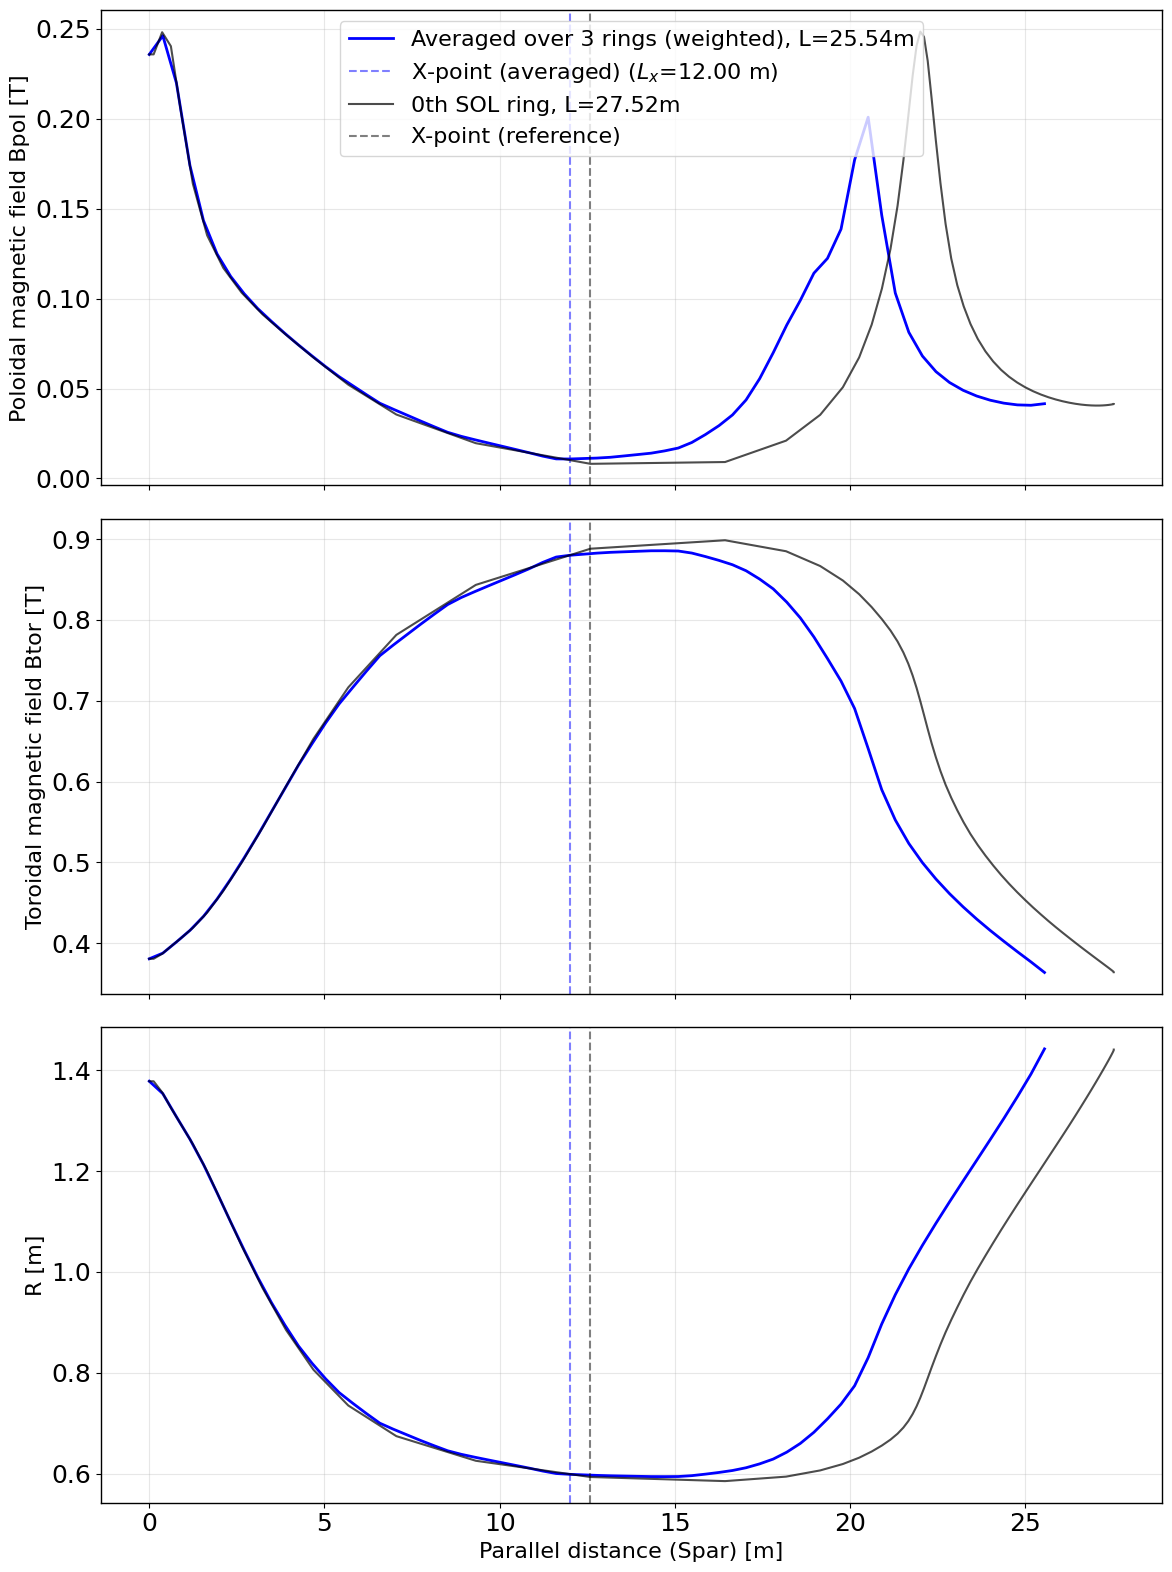

In [9]:
from scipy.interpolate import interp1d
import numpy as np

def average_flux_tubes(case, sepadd=None, sepdist=None, region='outer_lower', 
                      lambda_q_method=None, plot=False, weight_by_area=True):
    """
    Averages SOLPS geometry profiles over SOL rings.
    
    Uses normalized coordinates (0-1) so that equivalent positions along each flux tube
    are averaged together, preserving the relationship between geometry and connection length.

    Arguments:
        case: The case object providing get_1d_poloidal_data().
        sepadd: Number of SOL rings to average (e.g., 3 means average rings 0, 1, 2).
                If None, must specify sepdist or lambda_q_method.
        sepdist: Radial distance from separatrix [m]. Average over all rings within this distance.
        region: SOL ring region ('outer_lower', etc.)
        lambda_q_method: Method to determine averaging distance using get_lambda_q.
                        Options: 'exponential', 'eich', 'gaussian'
        plot: If True, plot the averaged flux tube against the 0th sol ring.
        weight_by_area: If True, use inverse gs_par weighting at OMP (smaller gs_par gets more weight).
                       If False, use simple arithmetic averaging.
    Returns:
        data: dict with averaged profiles. The coordinate is 'Spar', averaged over flux tubes.
    """
    # Validate inputs
    n_methods = sum([sepadd is not None, sepdist is not None, lambda_q_method is not None])
    if n_methods == 0:
        raise ValueError("Must specify one of: sepadd, sepdist, or lambda_q_method")
    if n_methods > 1:
        raise ValueError("Specify only one of: sepadd, sepdist, or lambda_q_method")
    
    if lambda_q_method is not None and lambda_q_method not in ['exponential', 'eich', 'gaussian']:
        raise ValueError("lambda_q_method must be 'exponential', 'eich', or 'gaussian'")
    
    params = ["R", "Z", "Bpol", "Btor"]
    
    # Determine which rings to average
    if lambda_q_method is not None:
        # Use get_lambda_q to determine distance
        result = get_lambda_q(case, region='omp', method=lambda_q_method, 
                             plot=False, range=(0.0, None), 
                             go_from_peak=(lambda_q_method == 'exponential'))
        
        if result is None:
            raise ValueError(f"{lambda_q_method} fit failed - cannot determine averaging distance")
        
        if lambda_q_method == 'exponential':
            sepdist = result['lambda_q']
            print(f'Using λq (exponential) = {sepdist * 1000:.3f} mm')
        elif lambda_q_method == 'eich':
            sepdist = result['lambda_q']
            print(f'Using λq (Eich, S=1) = {sepdist * 1000:.3f} mm')
        elif lambda_q_method == 'gaussian':
            sepdist = result['fwhm']
            print(f'Using FWHM = {sepdist * 1000:.3f} mm')
    
    if sepdist is not None:
        # Get radial profile to determine which rings fall within sepdist
        radial_data = case.get_1d_radial_data(['apar'], region='omp', keep_geometry=True)
        distances = radial_data['dist'].values
        
        # Find indices within sepdist, but filter out any that are in the core
        all_indices = [i for i, d in enumerate(distances) if d <= sepdist]
        
        # Filter to only SOL rings (non-negative indices relative to separatrix)
        # Check which indices are actually accessible
        indices = []
        for i in all_indices:
            try:
                # Try to get this ring - if it fails, skip it
                test = case.get_1d_poloidal_data(params=['R'], region=region, 
                                                sepadd=i, target_first=False, guards=False)
                indices.append(i)
            except:
                # This index doesn't exist or is invalid
                continue
        
        if len(indices) == 0:
            raise ValueError(f"No valid SOL rings found within {sepdist*1000:.2f} mm from separatrix")
        
        print(f"Found {len(indices)} valid SOL rings within {sepdist*1000:.2f} mm")
        print(f"Ring indices: {indices}")
        print(f"Radial distances: {[f'{distances[i]*1000:.3f} mm' for i in indices]}")
    else:
        # Use sepadd directly
        indices = list(range(sepadd))
        print(f"Averaging over {sepadd} flux tubes (indices {indices})")
    
    # Collect flux tubes
    print(f"Collecting flux tubes...")
    flines = []
    for i in indices:
        fline = case.get_1d_poloidal_data(params=params + ['apar'], region=region, 
                                         sepadd=i, target_first=False, guards=False)
        flines.append(fline)
    
    # Get connection lengths
    lengths = [f['Spar'].values[-1] for f in flines]
    print(f"Connection lengths: {[f'{l:.2f} m' for l in lengths]}")
    
    # Calculate average connection length (with or without weighting)
    if weight_by_area:
        apar_at_omp = np.array([f['apar'].values[0] for f in flines])
        weights = 1.0 / apar_at_omp
        weights_normalized = weights / np.sum(weights)
        avg_length = np.sum(np.array(lengths) * weights_normalized)
        print(f"\nWeighted average connection length: {avg_length:.2f} m")
        print(f"gs_par at OMP: {apar_at_omp}")
        print(f"Normalized weights: {weights_normalized}")
    else:
        avg_length = np.mean(lengths)
        print(f"\nArithmetic average connection length: {avg_length:.2f} m")
    
    # Normalize and interpolate each flux tube to fractional coordinate (0 to 1)
    ref_npoints = len(flines[0]['Spar'].values)
    s_normalized = np.linspace(0, 1, ref_npoints)  # Common normalized grid
    
    params_to_interp = params + ['apar']
    tmp_data = {p: [] for p in params_to_interp}
    
    for f, L in zip(flines, lengths):
        spar_old = f['Spar'].values
        s_old_normalized = spar_old / L  # Normalize to 0-1
        
        for p in params_to_interp:
            vals_old = f[p].values
            interp_func = interp1d(s_old_normalized, vals_old, kind='linear', 
                                  bounds_error=False, fill_value='extrapolate')
            tmp_data[p].append(interp_func(s_normalized))
    
    # Convert to arrays
    data_arrays = {p: np.asarray(tmp_data[p]) for p in params_to_interp}
    
    # Compute weighted or unweighted averages
    avg_data = {}
    
    if weight_by_area:
        # Use inverse gs_par weighting (already calculated above)
        weights = weights_normalized[:, np.newaxis]  # Broadcast shape
        
        for p in params:
            avg_data[p] = np.sum(data_arrays[p] * weights, axis=0)
    else:
        # Simple arithmetic mean
        for p in params:
            avg_data[p] = np.mean(data_arrays[p], axis=0)
    
    # Scale normalized coordinate back to averaged connection length
    avg_data['Spar'] = s_normalized * avg_length
    
    # Create label for plotting
    if sepdist is not None:
        weight_str = 'weighted' if weight_by_area else 'unweighted'
        if lambda_q_method == 'exponential':
            label = fr'Averaged over λq={sepdist*1000:.2f}mm ({weight_str})'
        elif lambda_q_method == 'eich':
            label = fr'Averaged over λq(Eich)={sepdist*1000:.2f}mm ({weight_str})'
        elif lambda_q_method == 'gaussian':
            label = fr'Averaged over FWHM={sepdist*1000:.2f}mm ({weight_str})'
        else:
            label = fr'Averaged over {sepdist*1000:.2f}mm ({weight_str})'
    else:
        weight_str = 'weighted' if weight_by_area else 'unweighted'
        label = f'Averaged over {len(indices)} rings ({weight_str})'
    
    avg_data['_label'] = label
    
    # Plot if requested
    if plot:
        import matplotlib.pyplot as plt
        
        # Get reference (0th ring)
        ref = flines[0]
        ref_data = {p: ref[p].values for p in params}
        ref_data['Spar'] = ref['Spar'].values
        
        fig, axs = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
        
        # Find X-points
        xpoint_idx_avg = np.argmin(avg_data['Bpol'])
        xpoint_idx_ref = np.argmin(ref_data['Bpol'])
        
        # Bpol
        axs[0].plot(avg_data['Spar'], avg_data['Bpol'], 
                   label=f'{label}, L={avg_length:.2f}m', 
                   color='blue', linewidth=2)
        axs[0].axvline(avg_data['Spar'][xpoint_idx_avg], color='blue',  
                      linestyle='--', alpha=0.5, label=fr'X-point (averaged) ($L_x$={avg_data['Spar'][xpoint_idx_avg]:.2f} m)')
        axs[0].plot(ref_data['Spar'], ref_data['Bpol'], 
                   label=f'0th SOL ring, L={lengths[0]:.2f}m', color='black', alpha=0.7)
        axs[0].axvline(ref_data['Spar'][xpoint_idx_ref], color='black', 
                      linestyle='--', alpha=0.5, label='X-point (reference)')
        axs[0].set_ylabel('Poloidal magnetic field Bpol [T]')
        axs[0].legend()
        axs[0].grid(True, alpha=0.3)
        
        # Btor
        axs[1].plot(avg_data['Spar'], avg_data['Btor'], color='blue', linewidth=2)
        axs[1].axvline(avg_data['Spar'][xpoint_idx_avg], color='blue', 
                      linestyle='--', alpha=0.5)
        axs[1].plot(ref_data['Spar'], ref_data['Btor'], color='black', alpha=0.7)
        axs[1].axvline(ref_data['Spar'][xpoint_idx_ref], color='black', 
                      linestyle='--', alpha=0.5)
        axs[1].set_ylabel('Toroidal magnetic field Btor [T]')
        axs[1].grid(True, alpha=0.3)
        
        # R
        axs[2].plot(avg_data['Spar'], avg_data['R'], color='blue', linewidth=2)
        axs[2].axvline(avg_data['Spar'][xpoint_idx_avg], color='blue', 
                      linestyle='--', alpha=0.5)
        axs[2].plot(ref_data['Spar'], ref_data['R'], color='black', alpha=0.7)
        axs[2].axvline(ref_data['Spar'][xpoint_idx_ref], color='black', 
                      linestyle='--', alpha=0.5)
        axs[2].set_xlabel('Parallel distance (Spar) [m]')
        axs[2].set_ylabel('R [m]')
        axs[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return avg_data

# Example usage:

# Method 1: Specify number of rings directly
test1 = average_flux_tubes(case, sepadd=3, plot=True, weight_by_area=True)

# test4 = average_flux_tubes(case, lambda_q_method='eich', plot=True, weight_by_area=True)

# # Method 2: Specify radial distance
# test2 = average_flux_tubes(case, sepdist=0.002, plot=True, weight_by_area=True)

# # Method 3: Use lambda_q from exponential fit
# test3 = average_flux_tubes(case, lambda_q_method='exponential', plot=True, weight_by_area=True)

# # Method 4: Use lambda_q from Eich fit
# test4 = average_flux_tubes(case, lambda_q_method='eich', plot=True, weight_by_area=True)

# # Method 5: Use FWHM from Gaussian fit
# test5 = average_flux_tubes(case, lambda_q_method='gaussian', plot=True, weight_by_area=True)

# # # Compare weighted vs unweighted for same distance
# # test_weighted = average_flux_tubes(case, lambda_q_method='eich', plot=True, weight_by_area=True)
# test_unweighted = average_flux_tubes(case, lambda_q_method='eich', plot=True, weight_by_area=False)

Generating 1D grid from averaged SOLPS flux tubes
Averaging over 3 flux tubes (indices [0, 1, 2])
Connection lengths: ['27.52 m', '21.39 m', '18.78 m']

Weighted average connection length: 25.54 m
gs_par at OMP: [0.00073146 0.00300314 0.00513254]
Normalized weights: [0.72146064 0.17572164 0.10281772]

Averaged flux tube properties:
  Connection length: 25.5441 m
  X-point location: 11.9980 m (47.0% along flux tube)
  Label: Averaged over 3 rings (weighted)

Initial 1D grid lpar range: [0.060667, 25.598210] m
SOLPS lpar range: [0.000000, 25.544072] m
Rescaled 1D grid lpar range: [0.000000, 25.544072] m
Difference at endpoint: 0.000000000 m
Number of 1D points beyond SOLPS range: 0


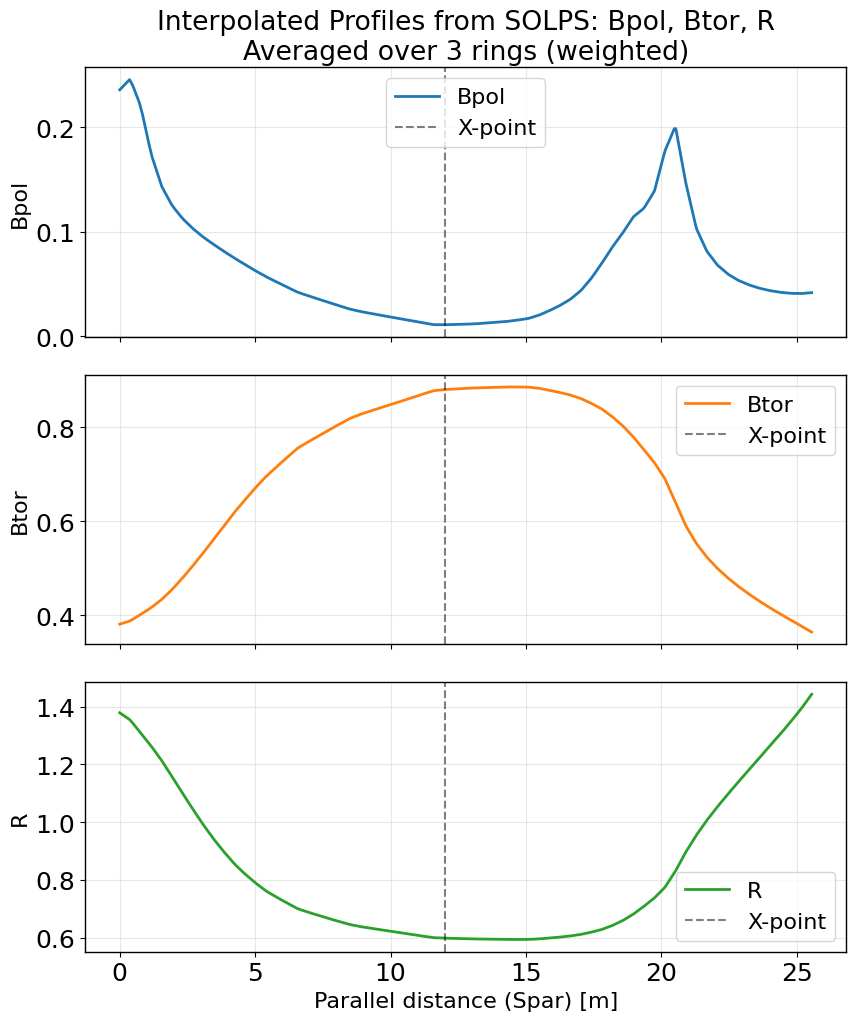


Interpolated data ranges:
  Bpol: [0.011, 0.245]
  Btor: [0.364, 0.886]
  R: [0.594, 1.442]

Writing NetCDF file: sol_ring_0-2_grid.nc

Created grid file: sol_ring_0-2_grid.nc


In [ ]:
# import numpy as np
# from netCDF4 import Dataset
# from scipy.interpolate import interp1d
# import matplotlib.pyplot as plt

# def grid_poloidal_profiles(
#     case,
#     nx=1,
#     ny=400,
#     nz=1,
#     dymin=0.1,
#     sepadd=None,
#     sepdist=None,
#     lambda_q_method=None,
#     region='outer_lower',
#     weight_by_area=True,
#     params=['Bpol', 'Btor', 'R'],
#     output_file='grid_1d_from_2d.nc',
#     plot_profiles=True
# ):
#     """
#     Generate a BOUT++ 1D grid file with magnetic/geometry data interpolated from SOLPS case.
    
#     Uses average_flux_tubes to handle flux tube averaging with proper geometric weighting.

#     Parameters
#     ----------
#     case : A SOLPS or Hermes3 case object with get_1d_poloidal_data method.
#     nx, ny, nz : int
#         3D grid dimensions (default 1, 400, 1).
#     dymin : float
#         Minimum grid spacing fraction (default 0.1).
#     sepadd : int or None
#         Number of SOL rings to average (e.g., 3 means average rings 0, 1, 2).
#         If None, must specify sepdist or lambda_q_method.
#     sepdist : float or None
#         Radial distance from separatrix [m]. Average over all rings within this distance.
#     lambda_q_method : str or None
#         Method to determine averaging distance using get_lambda_q.
#         Options: 'exponential', 'eich', 'gaussian'
#     region : str
#         Region for poloidal data (default 'outer_lower').
#     weight_by_area : bool
#         If True, use inverse gs_par weighting at OMP (smaller gs_par gets more weight).
#         If False, use simple arithmetic averaging.
#     params : list of str
#         List of SOLPS parameters to interpolate and save (default ['Bpol', 'Btor', 'R']).
#         Note: 'Bpol' must be included to find X-point location.
#     output_file : str
#         Filename to write grid NetCDF to.
#     plot_profiles : bool
#         If True, plot each interpolated profile on its own subplot against Spar.
        
#     Returns
#     -------
#     str
#         Path to created grid file
#     """
#     # Ensure Bpol is included for X-point detection
#     if 'Bpol' not in params:
#         params_with_bpol = params + ['Bpol']
#         bpol_added = True
#     else:
#         params_with_bpol = params
#         bpol_added = False
    
#     print("=" * 60)
#     print("Generating 1D grid from averaged SOLPS flux tubes")
#     print("=" * 60)
    
#     # Use average_flux_tubes to get the averaged profiles
#     avg_data = average_flux_tubes(
#         case=case,
#         sepadd=sepadd,
#         sepdist=sepdist,
#         region=region,
#         lambda_q_method=lambda_q_method,
#         plot=False,
#         weight_by_area=weight_by_area
#     )
    
#     # Extract the averaged 2D data
#     lpar_2d = avg_data['Spar']
#     profile_data_2d = {key: avg_data[key] for key in params_with_bpol}
    
#     # Find X-point location from averaged Bpol
#     xpoint_index = np.argmin(profile_data_2d['Bpol'])
#     length = lpar_2d[-1]
#     length_xpt = lpar_2d[xpoint_index]
    
#     print(f"\nAveraged flux tube properties:")
#     print(f"  Connection length: {length:.4f} m")
#     print(f"  X-point location: {length_xpt:.4f} m ({length_xpt/length*100:.1f}% along flux tube)")
#     print(f"  Label: {avg_data.get('_label', 'N/A')}")
    
#     # BOUT++ grid in y: [0, 2pi)
#     y_bout = np.linspace(0, 2*np.pi, ny, endpoint=False)

#     # Non-uniform dy definition
#     dy_array = (length / ny) * (1 + (1 - dymin) * (1 - y_bout / np.pi))

#     # Integrate dy to get the 1D grid's lpar
#     lpar_1d = np.zeros(ny)
#     lpar_1d[0] = 0.5 * dy_array[0]
#     for i in range(1, ny):
#         lpar_1d[i] = lpar_1d[i-1] + 0.5 * (dy_array[i-1] + dy_array[i])
        
#     print(f"\nInitial 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
#     print(f"SOLPS lpar range: [{lpar_2d[0]:.6f}, {lpar_2d[-1]:.6f}] m")

#     # Rescale lpar_1d to the exact SOLPS range
#     lpar_solps_min = lpar_2d[0]
#     lpar_solps_max = lpar_2d[-1]
#     lpar_1d = lpar_solps_min + (lpar_1d - lpar_1d[0]) * (lpar_solps_max - lpar_solps_min) / (lpar_1d[-1] - lpar_1d[0])

#     print(f"Rescaled 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
#     print(f"Difference at endpoint: {lpar_1d[-1] - lpar_solps_max:.9f} m")
#     print(f"Number of 1D points beyond SOLPS range: {np.sum(lpar_1d > lpar_solps_max)}")

#     # Use actual length for this grid
#     length = lpar_solps_max
    
#     # Calculate X-point location in y
#     source = length_xpt / length
#     y_xpt = np.pi * (2 - dymin - np.sqrt((2 - dymin)**2 - 4*(1 - dymin)*source)) / (1 - dymin)

#     # Interpolate averaged SOLPS parameters to 1D BOUT++ grid coordinates
#     profile_data_1d = {}
#     for key in params_with_bpol:
#         interp_func = interp1d(lpar_2d, profile_data_2d[key], kind='linear', 
#                               bounds_error=False, fill_value='extrapolate')
#         profile_data_1d[key] = interp_func(lpar_1d)

#     # Plot each interpolated profile on its own subplot if requested
#     if plot_profiles:
#         # Only plot the requested params (not Bpol if it was added automatically)
#         plot_params = params if not bpol_added else params_with_bpol
        
#         nparams = len(plot_params)
#         fig, axes = plt.subplots(nparams, 1, figsize=(9, 3.5 * nparams), sharex=True)
        
#         title_str = f"Interpolated Profiles from SOLPS: {', '.join(plot_params)}"
#         title_str += f"\n{avg_data.get('_label', 'Averaged flux tube')}"
        
#         if nparams == 1:
#             axes = [axes]
        
#         axes[0].set_title(title_str)
#         prop_cycle = plt.rcParams['axes.prop_cycle']
#         colors = prop_cycle.by_key()['color']
        
#         for idx, key in enumerate(plot_params):
#             color = colors[idx % len(colors)]
#             ax = axes[idx]
#             ax.plot(lpar_1d, profile_data_1d[key], label=key, color=color, linewidth=2)
#             ax.axvline(length_xpt, color='k', linestyle='--', alpha=0.5, label='X-point')
#             ax.set_ylabel(f'{key}')
#             ax.grid(True, alpha=0.3)
#             ax.legend()
        
#         axes[-1].set_xlabel('Parallel distance (Spar) [m]')
#         plt.tight_layout()
#         plt.show()
    
#     # Show interpolated ranges
#     print("\nInterpolated data ranges:")
#     for key in params:
#         print(f"  {key}: [{np.min(profile_data_1d[key]):.3f}, {np.max(profile_data_1d[key]):.3f}]")
    
#     # Write NetCDF grid file
#     print(f"\nWriting NetCDF file: {output_file}")
#     with Dataset(output_file, 'w', format='NETCDF3_CLASSIC') as ncfile:
#         # Create dimensions and size variables
#         ncfile.createDimension('x', nx)
#         ncfile.createDimension('y', ny)
#         ncfile.createDimension('z', nz)

#         nx_var = ncfile.createVariable('nx', 'i4')
#         ny_var = ncfile.createVariable('ny', 'i4')
#         nz_var = ncfile.createVariable('nz', 'i4')
#         nx_var[:] = nx
#         ny_var[:] = ny
#         nz_var[:] = nz

#         # Uniform/cell spacing
#         dx_var = ncfile.createVariable('dx', 'f8', ('x', 'y'))
#         dx_var[:, :] = 0.01

#         dy_var = ncfile.createVariable('dy', 'f8', ('x', 'y'))
#         dy_var[0, :] = dy_array

#         dz_var = ncfile.createVariable('dz', 'f8')
#         dz_var[:] = 2.0 * np.pi / nz

#         # Jacobian
#         J_var = ncfile.createVariable('J', 'f8', ('x', 'y'))
#         J_var[:, :] = 1.0

#         # Separatrix indices
#         ixseps1_var = ncfile.createVariable('ixseps1', 'i4')
#         ixseps1_var[:] = -1
#         ixseps2_var = ncfile.createVariable('ixseps2', 'i4')
#         ixseps2_var[:] = -1

#         # X-point location
#         y_xpt_var = ncfile.createVariable('y_xpt', 'f8')
#         y_xpt_var[:] = y_xpt

#         # Save interpolated profiles as 3D arrays (x, y, z)
#         for key in params:
#             arr3d = profile_data_1d[key].reshape(1, ny, 1)
#             units = None
#             long_name = None
            
#             # Standard units/long names
#             if key.lower() in ['poloidal_magnetic_field']:
#                 units = 'T'
#                 long_name = 'Poloidal magnetic field from 2D simulation'
#             elif key.lower() in ['toroidal_magnetic_field']:
#                 units = 'T'
#                 long_name = 'Toroidal magnetic field from 2D simulation'
#             elif key.lower() in ['fieldline_radius']:
#                 units = 'm'
#                 long_name = 'Major radius from 2D simulation'
#             else:
#                 units = ''
#                 long_name = f'{key} profile from SOLPS'
            
#             # Add averaging info to long_name
#             long_name += f' ({avg_data.get("_label", "averaged")})'
            
#             var = ncfile.createVariable(key, 'f8', ('x', 'y', 'z'))
#             var[:, :, :] = arr3d
#             var.units = units
#             var.long_name = long_name

#         # Also store the lpar coordinate vector for reference
#         lpar_var = ncfile.createVariable('lpar', 'f8', ('y',))
#         lpar_var[:] = lpar_1d
#         lpar_var.units = 'm'
#         lpar_var.long_name = 'Parallel distance along field line'

#         # Metadata
#         ncfile.description = '1D grid with interpolated data from averaged 2D SOLPS flux tubes'
#         ncfile.source_2d = 'SOLPS-ITER data'
#         ncfile.averaging_method = avg_data.get('_label', 'unknown')
#         ncfile.connection_length = float(length)
#         ncfile.xpoint_location = float(length_xpt)
#         ncfile.weighted_averaging = 'yes' if weight_by_area else 'no'
        
#         # Store averaging parameters
#         if sepadd is not None:
#             ncfile.sepadd = int(sepadd)
#         if sepdist is not None:
#             ncfile.sepdist = float(sepdist)
#         if lambda_q_method is not None:
#             ncfile.lambda_q_method = lambda_q_method

#     print(f"\nCreated grid file: {output_file}")
#     print("=" * 60)
#     return output_file


# # Example usage showing different averaging methods:

# if __name__ == "__main__":
#     # Method 1: Specify number of rings directly
#     grid_poloidal_profiles(case, sepadd=3, output_file='sol_ring_0-2_grid.nc', 
#                           weight_by_area=True)

#     # # Method 2: Use exponential lambda_q for averaging distance
#     # grid_poloidal_profiles(case, lambda_q_method='exponential', 
#     #                       output_file='grid_lambda_q_exp.nc', 
#     #                       weight_by_area=True)

#     # # Method 3: Use Eich lambda_q
#     # grid_poloidal_profiles(case, lambda_q_method='eich', 
#     #                       output_file='grid_lambda_q_eich.nc', 
#     #                       weight_by_area=True)

#     # # Method 4: Specify exact radial distance
#     # grid_poloidal_profiles(case, sepdist=0.002, 
#     #                       output_file='grid_sepdist_2mm.nc', 
#     #                       weight_by_area=True)

#     # # Method 5: Compare weighted vs unweighted
#     # grid_poloidal_profiles(case, lambda_q_method='eich', 
#     #                       output_file='grid_eich_unweighted.nc', 
#     #                       weight_by_area=False)

Generating 1D grid from averaged SOLPS flux tubes
Averaging over 1 flux tubes (indices [0])
Connection lengths: ['27.52 m']

Weighted average connection length: 27.52 m
gs_par at OMP: [0.00073146]
Normalized weights: [1.]

Averaged flux tube properties:
  Connection length: 27.5207 m
  X-point location: 12.9264 m (47.0% along flux tube)
  Label: Averaged over 1 rings (weighted)

Initial 1D grid lpar range: [0.065362, 27.579029] m
SOLPS lpar range: [0.000000, 27.520702] m
Rescaled 1D grid lpar range: [0.000000, 27.520702] m
Difference at endpoint: 0.000000000 m
Number of 1D points beyond SOLPS range: 0


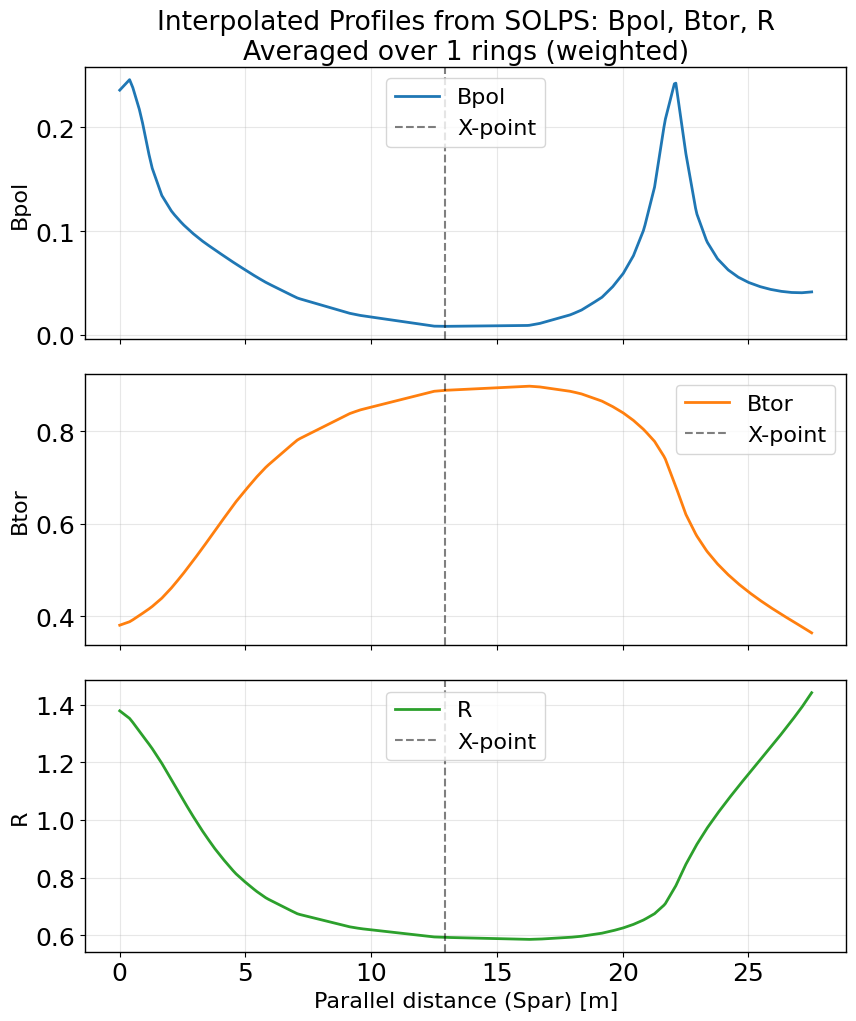


Interpolated data ranges:
  Bpol: [0.008, 0.246]
  Btor: [0.364, 0.898]
  R: [0.585, 1.441]

Writing NetCDF file: sol_ring_0_grid.nc

Created grid file: sol_ring_0_grid.nc


'sol_ring_0_grid.nc'

In [17]:
import numpy as np
from netCDF4 import Dataset
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def grid_poloidal_profiles(
    case,
    nx=1,
    ny=400,
    nz=1,
    dymin=0.1,
    sepadd=None,
    sepdist=None,
    lambda_q_method=None,
    region='outer_lower',
    weight_by_area=True,
    params=['Bpol', 'Btor', 'R'],
    output_file='grid_1d_from_2d.nc',
    plot_profiles=True
):
    """
    Generate a BOUT++ 1D grid file with magnetic/geometry data interpolated from SOLPS case.
    
    Uses average_flux_tubes to handle flux tube averaging with proper geometric weighting.

    Parameters
    ----------
    case : A SOLPS or Hermes3 case object with get_1d_poloidal_data method.
    nx, ny, nz : int
        3D grid dimensions (default 1, 400, 1).
    dymin : float
        Minimum grid spacing fraction (default 0.1).
    sepadd : int or None
        Number of SOL rings to average (e.g., 3 means average rings 0, 1, 2).
        If None, must specify sepdist or lambda_q_method.
    sepdist : float or None
        Radial distance from separatrix [m]. Average over all rings within this distance.
    lambda_q_method : str or None
        Method to determine averaging distance using get_lambda_q.
        Options: 'exponential', 'eich', 'gaussian'
    region : str
        Region for poloidal data (default 'outer_lower').
    weight_by_area : bool
        If True, use inverse gs_par weighting at OMP (smaller gs_par gets more weight).
        If False, use simple arithmetic averaging.
    params : list of str
        List of SOLPS parameters to interpolate and save (default ['Bpol', 'Btor', 'R']).
        Note: 'Bpol' must be included to find X-point location.
    output_file : str
        Filename to write grid NetCDF to.
    plot_profiles : bool
        If True, plot each interpolated profile on its own subplot against Spar.
        
    Returns
    -------
    str
        Path to created grid file
    """
    # Mapping from SOLPS names to BOUT++ names
    name_mapping = {
        'Bpol': 'poloidal_magnetic_field',
        'Btor': 'toroidal_magnetic_field',
        'R': 'fieldline_radius'
    }
    
    # Ensure Bpol is included for X-point detection
    if 'Bpol' not in params:
        params_with_bpol = params + ['Bpol']
        bpol_added = True
    else:
        params_with_bpol = params
        bpol_added = False
    
    print("=" * 60)
    print("Generating 1D grid from averaged SOLPS flux tubes")
    print("=" * 60)
    
    # Use average_flux_tubes to get the averaged profiles
    avg_data = average_flux_tubes(
        case=case,
        sepadd=sepadd,
        sepdist=sepdist,
        region=region,
        lambda_q_method=lambda_q_method,
        plot=False,
        weight_by_area=weight_by_area
    )
    
    # Extract the averaged 2D data
    lpar_2d = avg_data['Spar']
    profile_data_2d = {key: avg_data[key] for key in params_with_bpol}
    
    # Find X-point location from averaged Bpol
    xpoint_index = np.argmin(profile_data_2d['Bpol'])
    length = lpar_2d[-1]
    length_xpt = lpar_2d[xpoint_index]
    
    print(f"\nAveraged flux tube properties:")
    print(f"  Connection length: {length:.4f} m")
    print(f"  X-point location: {length_xpt:.4f} m ({length_xpt/length*100:.1f}% along flux tube)")
    print(f"  Label: {avg_data.get('_label', 'N/A')}")
    
    # BOUT++ grid in y: [0, 2pi)
    y_bout = np.linspace(0, 2*np.pi, ny, endpoint=False)

    # Non-uniform dy definition
    dy_array = (length / ny) * (1 + (1 - dymin) * (1 - y_bout / np.pi))

    # Integrate dy to get the 1D grid's lpar
    lpar_1d = np.zeros(ny)
    lpar_1d[0] = 0.5 * dy_array[0]
    for i in range(1, ny):
        lpar_1d[i] = lpar_1d[i-1] + 0.5 * (dy_array[i-1] + dy_array[i])
        
    print(f"\nInitial 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
    print(f"SOLPS lpar range: [{lpar_2d[0]:.6f}, {lpar_2d[-1]:.6f}] m")

    # Rescale lpar_1d to the exact SOLPS range
    lpar_solps_min = lpar_2d[0]
    lpar_solps_max = lpar_2d[-1]
    lpar_1d = lpar_solps_min + (lpar_1d - lpar_1d[0]) * (lpar_solps_max - lpar_solps_min) / (lpar_1d[-1] - lpar_1d[0])

    print(f"Rescaled 1D grid lpar range: [{lpar_1d[0]:.6f}, {lpar_1d[-1]:.6f}] m")
    print(f"Difference at endpoint: {lpar_1d[-1] - lpar_solps_max:.9f} m")
    print(f"Number of 1D points beyond SOLPS range: {np.sum(lpar_1d > lpar_solps_max)}")

    # Use actual length for this grid
    length = lpar_solps_max
    
    # Calculate X-point location in y
    source = length_xpt / length
    y_xpt = np.pi * (2 - dymin - np.sqrt((2 - dymin)**2 - 4*(1 - dymin)*source)) / (1 - dymin)

    # Interpolate averaged SOLPS parameters to 1D BOUT++ grid coordinates
    profile_data_1d = {}
    for key in params_with_bpol:
        interp_func = interp1d(lpar_2d, profile_data_2d[key], kind='linear', 
                              bounds_error=False, fill_value='extrapolate')
        profile_data_1d[key] = interp_func(lpar_1d)

    # Plot each interpolated profile on its own subplot if requested
    if plot_profiles:
        # Only plot the requested params (not Bpol if it was added automatically)
        plot_params = params if not bpol_added else params_with_bpol
        
        nparams = len(plot_params)
        fig, axes = plt.subplots(nparams, 1, figsize=(9, 3.5 * nparams), sharex=True)
        
        title_str = f"Interpolated Profiles from SOLPS: {', '.join(plot_params)}"
        title_str += f"\n{avg_data.get('_label', 'Averaged flux tube')}"
        
        if nparams == 1:
            axes = [axes]
        
        axes[0].set_title(title_str)
        prop_cycle = plt.rcParams['axes.prop_cycle']
        colors = prop_cycle.by_key()['color']
        
        for idx, key in enumerate(plot_params):
            color = colors[idx % len(colors)]
            ax = axes[idx]
            ax.plot(lpar_1d, profile_data_1d[key], label=key, color=color, linewidth=2)
            ax.axvline(length_xpt, color='k', linestyle='--', alpha=0.5, label='X-point')
            ax.set_ylabel(f'{key}')
            ax.grid(True, alpha=0.3)
            ax.legend()
        
        axes[-1].set_xlabel('Parallel distance (Spar) [m]')
        plt.tight_layout()
        plt.show()
    
    # Show interpolated ranges
    print("\nInterpolated data ranges:")
    for key in params:
        print(f"  {key}: [{np.min(profile_data_1d[key]):.3f}, {np.max(profile_data_1d[key]):.3f}]")
    
    # Write NetCDF grid file
    print(f"\nWriting NetCDF file: {output_file}")
    with Dataset(output_file, 'w', format='NETCDF3_CLASSIC') as ncfile:
        # Create dimensions and size variables
        ncfile.createDimension('x', nx)
        ncfile.createDimension('y', ny)
        ncfile.createDimension('z', nz)

        nx_var = ncfile.createVariable('nx', 'i4')
        ny_var = ncfile.createVariable('ny', 'i4')
        nz_var = ncfile.createVariable('nz', 'i4')
        nx_var[:] = nx
        ny_var[:] = ny
        nz_var[:] = nz

        # Uniform/cell spacing
        dx_var = ncfile.createVariable('dx', 'f8', ('x', 'y'))
        dx_var[:, :] = 0.01

        dy_var = ncfile.createVariable('dy', 'f8', ('x', 'y'))
        dy_var[0, :] = dy_array

        dz_var = ncfile.createVariable('dz', 'f8')
        dz_var[:] = 2.0 * np.pi / nz

        # Jacobian
        J_var = ncfile.createVariable('J', 'f8', ('x', 'y'))
        J_var[:, :] = 1.0

        # Separatrix indices
        ixseps1_var = ncfile.createVariable('ixseps1', 'i4')
        ixseps1_var[:] = -1
        ixseps2_var = ncfile.createVariable('ixseps2', 'i4')
        ixseps2_var[:] = -1

        # X-point location
        y_xpt_var = ncfile.createVariable('y_xpt', 'f8')
        y_xpt_var[:] = y_xpt

        # Save interpolated profiles as 3D arrays (x, y, z)
        for key in params:
            # Get the BOUT++ name for this variable
            bout_name = name_mapping.get(key, key)
            
            arr3d = profile_data_1d[key].reshape(1, ny, 1)
            
            # Set units and long names based on BOUT++ variable name
            if bout_name == 'poloidal_magnetic_field':
                units = 'T'
                long_name = 'Poloidal magnetic field from 2D simulation'
            elif bout_name == 'toroidal_magnetic_field':
                units = 'T'
                long_name = 'Toroidal magnetic field from 2D simulation'
            elif bout_name == 'fieldline_radius':
                units = 'm'
                long_name = 'Major radius from 2D simulation'
            else:
                units = ''
                long_name = f'{key} profile from SOLPS'
            
            # Add averaging info to long_name
            long_name += f' ({avg_data.get("_label", "averaged")})'
            
            # Create variable with BOUT++ name
            var = ncfile.createVariable(bout_name, 'f8', ('x', 'y', 'z'))
            var[:, :, :] = arr3d
            var.units = units
            var.long_name = long_name

        # Also store the lpar coordinate vector for reference
        lpar_var = ncfile.createVariable('lpar', 'f8', ('y',))
        lpar_var[:] = lpar_1d
        lpar_var.units = 'm'
        lpar_var.long_name = 'Parallel distance along field line'

        # Metadata
        ncfile.description = '1D grid with interpolated data from averaged 2D SOLPS flux tubes'
        ncfile.source_2d = 'SOLPS-ITER data'
        ncfile.averaging_method = avg_data.get('_label', 'unknown')
        ncfile.connection_length = float(length)
        ncfile.xpoint_location = float(length_xpt)
        ncfile.weighted_averaging = 'yes' if weight_by_area else 'no'
        
        # Store averaging parameters
        if sepadd is not None:
            ncfile.sepadd = int(sepadd)
        if sepdist is not None:
            ncfile.sepdist = float(sepdist)
        if lambda_q_method is not None:
            ncfile.lambda_q_method = lambda_q_method

    print(f"\nCreated grid file: {output_file}")
    print("=" * 60)
    return output_file


# Example usage showing different averaging methods:

grid_poloidal_profiles(case, sepadd=1, output_file='sol_ring_0_grid.nc', 
                        weight_by_area=True)

    # # Method 2: Use exponential lambda_q for averaging distance
    # grid_poloidal_profiles(case, lambda_q_method='exponential', 
    #                       output_file='grid_lambda_q_exp.nc', 
    #                       weight_by_area=True)

    # # Method 3: Use Eich lambda_q
    # grid_poloidal_profiles(case, lambda_q_method='eich', 
    #                       output_file='grid_lambda_q_eich.nc', 
    #                       weight_by_area=True)

    # # Method 4: Specify exact radial distance
    # grid_poloidal_profiles(case, sepdist=0.002, 
    #                       output_file='grid_sepdist_2mm.nc', 
    #                       weight_by_area=True)

    # # Method 5: Compare weighted vs unweighted
    # grid_poloidal_profiles(case, lambda_q_method='eich', 
    #                       output_file='grid_eich_unweighted.nc', 
    #                       weight_by_area=False)

# Power/particle sources

In [11]:
def calculate_parallel_power_xpoint(case, sepadd=0, sepdist=None, region='outer_lower', 
                                   verbose=True, lambda_q_method=None, plot=False):
    """
    Calculate parallel power at the X-point by summing over SOL rings.
    
    Arguments:
        case: The case object
        sepadd: Number of SOL rings to sum over
        sepdist: Radial distance from separatrix to sum over
        region: Region to analyze ('outer_lower', etc.)
        lambda_q_method: If specified, use get_lambda_q to determine radial extent.
                        Options: 'exponential', 'eich', 'gaussian'
                        - 'exponential': simple exponential decay fit
                        - 'eich': Eich profile fit (returns lambda_q)
                        - 'gaussian': Gaussian fit (returns FWHM)
        verbose: If True, print results
        plot: Not used currently
    
    Returns:
        dict: Dictionary containing:
            - 'total_src': Total parallel heat flux at X-point [W/m²]
            - 'e_src': Electron heat flux at X-point [W/m²]
            - 'i_src': Ion heat flux at X-point [W/m²]
            - 'src_ratio': Electron/ion ratio
    """
    # Validate inputs
    if sum([lambda_q_method is not None, sepdist is not None, sepadd != 0]) > 1:
        raise ValueError("Specify only one of: sepadd, sepdist, or lambda_q_method")
    
    if lambda_q_method is not None and lambda_q_method not in ['exponential', 'eich', 'gaussian']:
        raise ValueError("lambda_q_method must be 'exponential', 'eich', or 'gaussian'")
    
    e_src = 0
    i_src = 0
    total_src = 0 

    # Determine radial extent using lambda_q_method
    if lambda_q_method is not None:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty"],
            region='omp',
            keep_geometry=False,
        )
        
        result = get_lambda_q(case, region='omp', method=lambda_q_method, 
                             plot=False, range=(0.0, None),
                             go_from_peak=(lambda_q_method == 'exponential'))
        
        if result is None:
            raise ValueError(f"{lambda_q_method} fit failed - cannot determine radial extent")
        
        if lambda_q_method == 'exponential':
            sepdist = result['lambda_q']
            print(f"Using λq (exponential) = {sepdist*1000:.2f} mm")
        
        elif lambda_q_method == 'eich':
            sepdist = result['lambda_q']
            print(f"Using λq (Eich, S=1) = {sepdist*1000:.2f} mm")
        
        elif lambda_q_method == 'gaussian':
            sepdist = result['fwhm']
            print(f"Using FWHM = {sepdist*1000:.2f} mm")
        
        # Count SOL flux tubes within the determined distance
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Summing over {sepadd + 1} flux tubes")

    elif sepdist is not None:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty"],
            region='omp',
            keep_geometry=False,
        )
        # Count SOL flux tubes within sepdist
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Found {sepadd + 1} flux tubes within {sepdist*1000:.2f} mm")

    # Sum parallel power at X-point across flux tubes
    for i in range(sepadd + 1):
        fline = case.get_1d_poloidal_data(
            params=["fhex_total", "fhix_total", "Bpol", "fhtx", "fhty", "gs_par", "gs_perp"],
            region=region,
            sepadd=i,
            target_first=False,
            guards=False,
        )
        xpoint_idx = np.argmin(fline['Bpol'])
        total_src += (fline['fhex_total'][xpoint_idx] + fline['fhix_total'][xpoint_idx])/fline['gs_par'][xpoint_idx]
        e_src += fline['fhex_total'][xpoint_idx]/fline['gs_par'][xpoint_idx]
        i_src += fline['fhix_total'][xpoint_idx]/fline['gs_par'][xpoint_idx]
    
    src_ratio = e_src/i_src if i_src != 0 else np.inf

    if verbose:
        print(f"Electron source: {e_src:.2e} W/m²")
        print(f"Ion source: {i_src:.2e} W/m²")
        print(f"Total source: {total_src:.2e} W/m²")
        print(f"e/i ratio: {src_ratio:.2f}")

    return {'total_src': total_src, 'e_src': e_src, 'i_src': i_src, 'src_ratio': src_ratio}


# Example usage:

# Using Eich fit
result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='eich')
print(f"Results: {result}")

# Using exponential fit
result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='exponential')

# Using Gaussian FWHM
result = calculate_parallel_power_xpoint(case, region='outer_lower', lambda_q_method='gaussian')

# Manual distance specification (backwards compatible)
# result = calculate_parallel_power_xpoint(case, region='outer_lower', sepdist=0.005)

# # Manual ring count (backwards compatible)
# result = calculate_parallel_power_xpoint(case, region='outer_lower', sepadd=3)

Initial guesses: q0=6.51e+06, λq=5.00mm, q_bg=0.00e+00

Eich fit parameters:
  q₀: 7.19e+06 ± 2.54e+05 W/m²
  λq: 3.36 ± 0.29 mm
  q_BG: 1.48e-21 ± 4.05e+04 W/m²
Using λq (Eich, S=1) = 3.36 mm
Summing over 4 flux tubes
Electron source: 1.30e+06 W/m²
Ion source: 3.28e+05 W/m²
Total source: 1.63e+06 W/m²
e/i ratio: 3.96
Results: {'total_src': np.float64(1625515.9287879358), 'e_src': np.float64(1297894.0198471649), 'i_src': np.float64(327621.90894077055), 'src_ratio': np.float64(3.9615605196959094)}
Exponential fit:
  λq: 1.86 mm
  Amplitude: 4.20e+06 W/m²
Using λq (exponential) = 1.86 mm
Summing over 3 flux tubes
Electron source: 1.05e+06 W/m²
Ion source: 2.26e+05 W/m²
Total source: 1.28e+06 W/m²
e/i ratio: 4.67
Gaussian fit parameters:
  Peak amplitude (a): 1.03e+07 W/m²
  Peak position (r0): -6.12 mm
  Sigma: 4.15 mm
  FWHM: 9.78 mm
Using FWHM = 9.78 mm
Summing over 7 flux tubes
Electron source: 1.52e+06 W/m²
Ion source: 4.54e+05 W/m²
Total source: 1.98e+06 W/m²
e/i ratio: 3.36


In [12]:
def calculate_average_density_omp(case, sepadd=0, sepdist=None, region='outer_lower', verbose=True,  
                                   use_lambda_q=False, use_fwhm=False, use_lambda_q_eich=False, 
                                   plot=False):
    """
    Calculate average plasma density at the outer midplane by averaging over SOL rings.

    Arguments:
        case: The case object
        sepadd: Number of SOL rings to average over
        sepdist: Radial distance from separatrix to average over
        region: Region to analyze ('outer_lower', etc.)
        use_lambda_q: If True, use lambda_q (simple exponential) to determine radial extent
        use_fwhm: If True, use FWHM of Gaussian fit to determine radial extent
        use_lambda_q_eich: If True, use lambda_q from Eich fit (S=1) to determine radial extent
        plot: Not used currently

    Returns:
        Average electron density at OMP [m⁻³]
    """
    # Validate inputs
    if sum([use_lambda_q, use_fwhm, use_lambda_q_eich, sepdist is not None, sepadd != 0]) > 1:
        raise ValueError("Specify only one of: sepadd, sepdist, use_lambda_q, use_fwhm, or use_lambda_q_eich")
    
    ne_sum = 0
    ne_values = []

    if use_lambda_q_eich:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol"],
            region='omp',
            keep_geometry=False,
        )
        sepdist, q0, q_bg = get_lambda_q_eich(case, region='omp', plot=False, range=(0.0, None))
        if sepdist is None:
            raise ValueError("Eich fit failed - cannot determine lambda_q")
        print(f"Using lambda_q (Eich, S=1) = {sepdist*1000:.2f} mm")
        
        # Count SOL flux tubes within lambda_q
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Averaging over {sepadd + 1} flux tubes")

    elif use_fwhm:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol"],
            region='omp',
            keep_geometry=False,
        )
        sepdist, *_ = get_fwhm_gaussian_q(case, region='omp', plot=False, range=(0.0, None))
        print(f"Using FWHM = {sepdist*1000:.2f} mm")
        
        # Count SOL flux tubes within FWHM
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Averaging over {sepadd + 1} flux tubes")

    elif sepdist is not None:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol"],
            region='omp',
            keep_geometry=False,
        )
        # Count SOL flux tubes within sepdist
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Found {sepadd + 1} flux tubes within {sepdist*1000:.2f} mm")
        
    elif use_lambda_q:
        fline_radial = case.get_1d_radial_data(
            params=["fhex_total", "fhix_total", "Bpol"],
            region='omp',
            keep_geometry=False,
        )
        sepdist, *_ = get_lambda_q(case, region='omp', plot=False, range=(0.0, None), go_from_peak=True)
        print(f"Using lambda_q (exponential) = {sepdist*1000:.2f} mm")
        
        # Count SOL flux tubes within lambda_q
        valid_mask = (fline_radial['dist'] >= 0) & (fline_radial['dist'] <= sepdist)
        sepadd = np.sum(valid_mask) - 1  # -1 because sepadd=0 is the separatrix
        print(f"Averaging over {sepadd + 1} flux tubes")

    # Loop through flux tubes and collect Ne at OMP (first grid index)
    for i in range(sepadd + 1):
        fline = case.get_1d_poloidal_data(
            params=["Ne"],
            region=region,
            sepadd=i,
            target_first=False,
            guards=False,
        )
        # First grid index is at the outer midplane
        omp_idx = 0
        ne_values.append(fline['Ne'][omp_idx])
        ne_sum += fline['Ne'][omp_idx]

    # Calculate average
    n_tubes = sepadd + 1
    ne_avg = ne_sum / n_tubes

    if verbose:
        print(f"Average density at OMP: {ne_avg:.2e} m⁻³")
        print(f"Min density: {min(ne_values):.2e} m⁻³")
        print(f"Max density: {max(ne_values):.2e} m⁻³")
        print(f"Number of flux tubes: {n_tubes}")
        print(f"Sum of densities at OMP: {ne_sum:.2e} m⁻³")
        print(f"List of densities at OMP: {ne_values}")

    return {'ne_avg': ne_avg, 'ne_sum': ne_sum, 'ne_values': ne_values, 'n_tubes': n_tubes}


# Example usage
result = calculate_average_density_omp(case, region='outer_lower', use_lambda_q_eich=True)
print(f"Result: {result}")

NameError: name 'get_lambda_q_eich' is not defined

# Generate 1D grid file

# Calculating sources from cross field flux

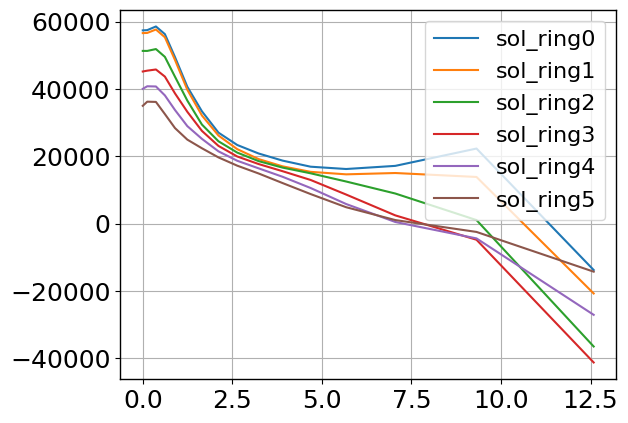

{'sol_ring0': array([ 57379.78685634,  57452.44507428,  58534.86846392,  56264.50555219,
        49434.32518268,  40635.9488282 ,  33351.8647748 ,  27018.36117421,
        23347.73715306,  20829.03271899,  18710.91241033,  16906.307082  ,
        16218.87995825,  17150.18244887,  22293.13387565, -13763.61185201]), 'sol_ring1': array([ 56570.01545873,  56620.37735268,  57635.47491936,  55337.34192853,
        48577.51397129,  39749.82768671,  32112.40471319,  26158.41902794,
        22114.42513766,  19168.6721315 ,  17006.18467214,  15378.8917884 ,
        14636.03536754,  15029.19608704,  13858.08048489, -20734.37671868]), 'sol_ring2': array([ 51283.72626415,  51279.05856944,  51828.36676457,  49515.64281418,
        43602.86777025,  36530.37225066,  29415.21224612,  24451.10571247,
        21090.65272838,  18565.5179169 ,  16632.62232744,  14948.07929438,
        12505.3696538 ,   8941.80416506,   1054.70627575, -36476.92416354]), 'sol_ring3': array([ 45169.67536415,  45416.77965915, 

In [ ]:
fig, ax = plt.subplots()
core_sol = {}
for i in range(6):
    fline_core = case.get_1d_poloidal_data(
        params=["fhey_total", 'fhiy_total', 'Bpol', 'gs_perp', 'gs_par','fhty'],
        region='outer_lower',
        sepadd = i,
        target_first=False,
        guards=False,
    )

    upstream = fline_core.query('region == "upstream"')

    if i == 0:
        sep_s = upstream['Spar']

    xpoint_indices = fline_core.index[fline_core["Xpoint"] == 1].tolist()
    # print(f"Indices where Xpoint == 1:", xpoint_indices)

    # print(len(fline_core))
    # print(fline_core['Spar'].iloc[-1])
    
    if len(upstream) > 0:
        power_src = upstream['fhty'].values/upstream['gs_perp'].values
        core_sol[f'sol_ring{i}'] = power_src
    # ax.axvline(fline_core['Spol'].iloc[xpoint_indices[0]], color='k', linestyle='--', alpha=0.5, label='x-point')


# After your loop completes, find max length
max_len = max(len(core_sol[key]) for key in core_sol.keys())

# # Pad each array
# for key in core_sol.keys():
#     core_sol[key] = np.pad(core_sol[key], (0, max_len - len(core_sol[key])), 
#                            constant_values=0)


for j in core_sol.keys():
    ax.plot(sep_s, core_sol[j], label=j)

ax.legend()
plt.show()


print(core_sol)

In [ ]:
core_sol = {}

for i in range(6):
    fline_core = case.get_1d_poloidal_data(
        params=["fhey_total", 'fhiy_total', 'Bpol', 'gs_perp', 'gs_par','fhty'],
        region='outer_lower',
        sepadd = i,
        target_first=False,
        guards=False,
    )
    upstream = fline_core.query('region == "upstream"')

    xpoint_indices = fline_core.index[fline_core["Xpoint"] == 1].tolist()
    print(f"Indices where Xpoint == 1:", xpoint_indices)

    print(len(fline_core))
    print(fline_core['Spar'].iloc[-1])
    
    if len(upstream) > 0:
        power_src = upstream['fhty'].values/upstream['gs_perp'].values
        core_sol[f'sol_ring{i}'] = power_src

# After your loop completes, find max length
max_len = max(len(core_sol[key]) for key in core_sol.keys())

# Pad each array
for key in core_sol.keys():
    core_sol[key] = np.pad(core_sol[key], (0, max_len - len(core_sol[key])), 
                           constant_values=0)

print(core_sol)


# far_sol = []    
# fline_far = case.get_1d_poloidal_data(
# params=["fhey_total", 'fhiy_total', 'Bpol', 'gs_perp', 'gs_par','fhty'],
# region='outer_lower',
# sepadd = 7,
# target_first=False,
# guards=False,
# )

# far_sol += fline_far.loc[fline_far['Xpoint'] == 1, 'fhey_total']/fline_far.loc[fline_far['Xpoint'] == 1, 'gs_perp']


# core_sol -= far_sol

# print(core_sol)
# fig, ax = plt.subplots()



# ax.axvline(fline.loc[fline['Xpoint'] == 1, 'Spar'].iloc[0], color='k', linestyle='--', alpha=0.5, label='x-point')
# ax.plot(fline['Spar'].values, fline['fhey_total'].values)
# ax.plot(fline['Spar'].values, fline['fhiy_total'].values)
# plt.show()




Indices where Xpoint == 1: [16]
67
27.520701887675383
Indices where Xpoint == 1: [16]
67
21.38914767808889
Indices where Xpoint == 1: [16]
67
18.775295814234926
Indices where Xpoint == 1: [16]
67
17.091356703365875
Indices where Xpoint == 1: [16]
67
15.886734538334983
Indices where Xpoint == 1: [16]
67
14.98955644264066
{'sol_ring0': array([ 57379.78685634,  57452.44507428,  58534.86846392,  56264.50555219,
        49434.32518268,  40635.9488282 ,  33351.8647748 ,  27018.36117421,
        23347.73715306,  20829.03271899,  18710.91241033,  16906.307082  ,
        16218.87995825,  17150.18244887,  22293.13387565, -13763.61185201]), 'sol_ring1': array([ 56570.01545873,  56620.37735268,  57635.47491936,  55337.34192853,
        48577.51397129,  39749.82768671,  32112.40471319,  26158.41902794,
        22114.42513766,  19168.6721315 ,  17006.18467214,  15378.8917884 ,
        14636.03536754,  15029.19608704,  13858.08048489, -20734.37671868]), 'sol_ring2': array([ 51283.72626415,  51279.058

# Build 1D geometry grid

# Generate sources

In [ ]:
def get_power_src(case, sol_rings=6, sum_result=True, plot_result=False):
    """
    Collects fhex_total up to (but not including) the X-point for rings in the SOL,
    and separately for the 'far' (ring outside the SOL) up to the X-point.
    If sum_result=True, returns sums (as before).
    If sum_result=False, returns the arrays up to X-point for each ring.
    Returns dict with 'p_sol' and 'p_far'. 'p_sol' is either a 1D array of totals (if summed)
    or a list of arrays, one per SOL ring (if not summed).
    """

    # We don't know the final shape up front, so use lists to collect, then stack at end
    p_sol_list = []
    p_far_result = None

    for i in range(sol_rings):
        fline_sol = case.get_1d_poloidal_data(
            params=["R", "Z", "fhex_total", 'fhix_total', 'Bpol', 'Btot'],
            region="outer_lower",
            sepadd=i,
            target_first=False,
            guards=False
        )
        xpt_indx = np.argmin(fline_sol['Bpol'])
        # Collect fhex_total up to X-point for this ring
        p_sol_list.append(np.array(fline_sol['fhex_total'][:xpt_indx]))

    # If sum_result: sum each, so p_sol is a 1D array for each ring (total power for each)
    # Else: provide arrays up to x-point for each ring
    if sum_result:
        p_sol = np.array([arr.sum() for arr in p_sol_list])
    else:
        p_sol = p_sol_list  # List of 1D arrays (power profile per ring up to X-point)

    # Get power in the 'far' region after X-point outside the SOL
    fline_far = case.get_1d_poloidal_data(
        params=["R", "Z", "fhex_total", 'fhix_total', 'Bpol', 'Btot'],
        region="outer_lower",
        sepadd=sol_rings + 1,
        target_first=False,
        guards=False
    )
    xpt_indx = np.argmin(fline_far['Bpol'])
    if sum_result:
        p_far = np.array(fline_far['fhex_total'][:xpt_indx]).sum()
    else:
        p_far = np.array(fline_far['fhex_total'][:xpt_indx])

    power_src = {'p_sol': p_sol, 'p_far': p_far}

    if plot_result and not sum_result:
        fig, ax = plt.subplots()
        ax.plot(power_src['p_sol'], label='SOL rings')
        ax.plot(power_src['p_far'], label='Far field')
        ax.set_xlabel('Ring index')
        ax.set_ylabel('Power [W/m]')
        fig.legend()

    elif plot_result and sum_result:
        print('Can only plot non-summed profiles')

    return power_src

# Example usage:
# Get only sums (default)
test_sum = get_power_src(case, sol_rings=6, sum_result=True)
print("Summed result:", test_sum)
print("all SOL:", test_sum['p_sol'].sum())

# Get arrays up to the x-point (profiles)
test_profiles = get_power_src(case, sol_rings=6, sum_result=False)
print("Profiles up to X-point:", test_profiles)
print("all SOL:", test_profiles['p_sol'][:].sum())


Summed result: {'p_sol': array([ 97026.83315018, 413926.09819378, 413781.27345575, 330798.35164613,
       282515.46326798, 642873.81669372]), 'p_far': np.float64(395203.49054968747)}
all SOL: 2180921.836407535
Profiles up to X-point: {'p_sol': [array([2310.58800258, 2728.53741403, 3366.17785827, 4021.77445407,
       4860.30520985, 5571.04965734, 6518.66203316, 7108.00376288,
       7472.99570899, 7930.24796426, 8438.81445892, 8879.65661684,
       9187.08382431, 9299.4128023 , 9333.52338238]), array([ 9713.71687092, 12280.14247921, 16581.79440808, 21069.3701293 ,
       26016.85802133, 30132.67656028, 32867.00703655, 34249.73948839,
       34558.24423504, 34275.00241097, 33659.82252196, 32906.15633976,
       32163.83349556, 31604.70831202, 31847.0258844 ]), array([ 9771.81788954, 12811.20305346, 17414.13757706, 21866.24772394,
       26806.73299971, 31318.08876249, 33699.27063684, 34530.71425987,
       34411.97134378, 33829.42360264, 32983.14940016, 32061.62700874,
       31179.262

AttributeError: 'list' object has no attribute 'sum'